# Image Captioning Dataset 

**Harpreet Singh** | IIT Bombay 

Built a dataset of 10,000+ images with AI-generated captions for training image captioning models.

What I did:
1. Scraped images from Pexels API across surveillance-relevant categories
2. Generated captions using BLIP (pretrained vision-language model)
3. Organized everything into a structured dataset with metadata

## Step 1: Setup and Imports

In [12]:
import requests
import os
import time
import json
import random
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import matplotlib.pyplot as plt
import csv

IMAGE_DIR = "images_hq"

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

## Step 2: Image Categories

I did chose the categories that are relevant to what Eagle Eye's surveillance cameras actually capture - people, vehicles, buildings, entrances, night scenes, crowds etc.

In [ ]:
CATEGORIES = {
    "people_walking": [
        "people walking street",
        "pedestrians sidewalk city",
        "person walking urban road",
        "people crossing road",
        "man walking alone street",
        "woman walking city"
    ],
    "street_scene": [
        "street scene urban",
        "city street daytime",
        "urban road buildings",
        "downtown street view",
        "residential street neighborhood",
        "busy city road"
    ],
    "parking_lot": [
        "parking lot cars",
        "car park outdoor",
        "parking garage vehicles",
        "parking area shopping mall",
        "underground parking",
        "parking space"
    ],
    "vehicles": [
        "vehicles cars road",
        "cars driving highway",
        "automobile traffic city",
        "car on street parked",
        "bus on road city",
        "motorcycle road urban"
    ],
    "office_building": [
        "office building exterior",
        "commercial building",
        "corporate building entrance",
        "modern office architecture",
        "skyscraper building city",
        "glass building facade"
    ],
    "indoor_spaces": [
        "indoor hallway corridor",
        "building interior hallway",
        "office corridor inside",
        "hotel lobby interior",
        "shopping mall interior",
        "warehouse interior"
    ],
    "crowd": [
        "crowd of people gathering",
        "group of people outdoor",
        "busy public place people",
        "people gathering event",
        "train station crowd",
        "market crowd people"
    ],
    "entrance_security": [
        "entrance door building",
        "building doorway entry",
        "security gate entrance",
        "glass door entrance office",
        "lobby entrance building",
        "turnstile entrance"
    ],
    "night_surveillance": [
        "night street city lights",
        "city night urban",
        "dark street lamps",
        "nighttime road cars",
        "night parking lot",
        "street night security"
    ],
    "traffic_vehicles": [
        "traffic intersection cars",
        "busy road traffic",
        "vehicles traffic light",
        "road junction cars",
        "highway traffic aerial",
        "traffic jam city"
    ],
    "security_camera_view": [
        "surveillance camera view",
        "cctv security monitoring",
        "security guard building",
        "gated community entrance",
        "warehouse security",
        "retail store interior"
    ],
    "outdoor_areas": [
        "campus outdoor walkway",
        "park pathway people",
        "sidewalk cafe outdoor",
        "public square city",
        "train platform station",
        "airport terminal people"
    ]
}

total_queries = sum(len(q) for q in CATEGORIES.values())
print(f"Categories: {len(CATEGORIES)}")
print(f"Total search queries: {total_queries}")
for cat, queries in CATEGORIES.items():
    print(f"  {cat}: {len(queries)} queries")

## Step 3: Scraping Images from Pexels API

Used Pexels API to download images. Some things I kept in mind while writing this:
- Used "large" size instead of "medium" because medium was giving very small images around 20-30kb
- Skipped images smaller than 640px width
- Skipped files under 50KB to filter out broken or thumbnail downloads
- Tracked Pexels photo IDs to avoid downloading same image twice across different queries

In [ ]:
API_KEY = "2o01TwDUMOlKQFA5sP2cH5j2WloD98PiiuC6BF393PBGSiBcOSho9xCF"

os.makedirs(IMAGE_DIR, exist_ok=True)

HEADERS = {"Authorization": API_KEY}
seen_ids = set()


def download_image(url, filepath):
    try:
        resp = requests.get(url, timeout=30)
        if resp.status_code == 200 and len(resp.content) > 50000:
            with open(filepath, "wb") as f:
                f.write(resp.content)
            return True
    except:
        pass
    return False


def scrape_query(query, category, start_id):
    count = 0
    page = 1
    metadata = []

    while True:
        params = {"query": query, "per_page": 80, "page": page}

        try:
            resp = requests.get("https://api.pexels.com/v1/search", headers=HEADERS, params=params, timeout=30)

            if resp.status_code == 429:
                time.sleep(60)
                continue

            if resp.status_code != 200:
                break

            photos = resp.json().get("photos", [])
            if not photos:
                break

            for photo in photos:
                if photo["id"] in seen_ids or photo["width"] < 640:
                    continue

                img_id = start_id + count
                fname = f"img_{img_id:05d}.jpg"
                fpath = os.path.join(IMAGE_DIR, fname)

                if download_image(photo["src"]["large"], fpath):
                    metadata.append({
                        "image_id": img_id,
                        "filename": fname,
                        "category": category,
                        "query": query,
                        "pexels_id": photo["id"],
                        "photographer": photo.get("photographer", "unknown"),
                        "width": photo["width"],
                        "height": photo["height"]
                    })
                    seen_ids.add(photo["id"])
                    count += 1

            page += 1
            time.sleep(1)

        except:
            time.sleep(5)
            continue

    return count, metadata

### Running the scraper
This took around 2-3 hours to finish because of API rate limits and download time.

In [ ]:
all_metadata = []
total = 0
next_id = 0

for cat_name, queries in CATEGORIES.items():
    print(f"\n--- {cat_name} ---")
    cat_count = 0

    for q in queries:
        if total >= 10500:
            break
        n, meta = scrape_query(q, cat_name, next_id)
        print(f"  '{q}' -> {n} images")
        all_metadata.extend(meta)
        cat_count += n
        total += n
        next_id += n

    print(f"  total for {cat_name}: {cat_count}")

    if total >= 10500:
        break

with open("image_metadata_hq.json", "w") as f:
    json.dump(all_metadata, f, indent=2)

print(f"\nDone. {len(all_metadata)} images saved.")

### Checking what got downloaded

In [10]:
with open("image_metadata_hq.json", "r") as f:
    metadata = json.load(f)

print(f"Total images: {len(metadata)}")
print(f"\nImages per category:")

cat_counts = {}
for item in metadata:
    cat = item["category"]
    cat_counts[cat] = cat_counts.get(cat, 0) + 1

for cat, count in cat_counts.items():
    print(f"  {cat}: {count}")

Total images: 10617

Images per category:
  people_walking: 1201
  street_scene: 1629
  parking_lot: 1044
  vehicles: 1157
  office_building: 1317
  indoor_spaces: 1086
  crowd: 1623
  entrance_security: 1083
  night_surveillance: 477


### Looking at some sample images from each category

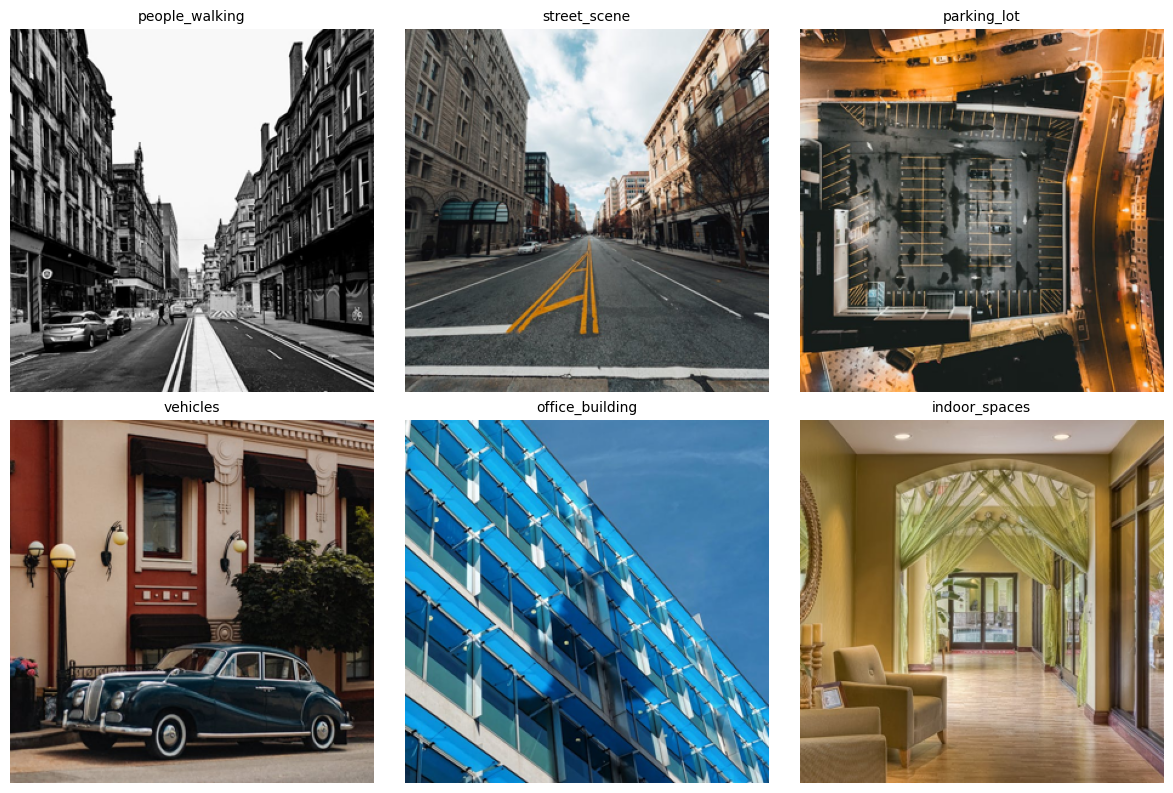

In [13]:
categories_list = list(cat_counts.keys())[:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for idx, ax in enumerate(axes.flat):
    cat = categories_list[idx]
    cat_images = [m for m in metadata if m["category"] == cat]
    sample = random.choice(cat_images)
    path = os.path.join(IMAGE_DIR, sample["filename"])

    if os.path.exists(path):
        img = Image.open(path).convert("RGB")
        w, h = img.size
        side = min(w, h)
        left = (w - side) // 2
        top = (h - side) // 2
        img = img.crop((left, top, left + side, top + side))
        img = img.resize((300, 300))
        ax.imshow(img)

    ax.set_title(cat, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Step 4: Generating Captions using BLIP

Used BLIP from Salesforce for captioning. Its a vision-language model trained on hundreds of millions of image-text pairs so it generates pretty good captions out of the box.

Generated two types of captions for each image:
- Basic caption - just let the model describe what it sees
- Detailed caption - gave it a prompt "a detailed description of" to get longer descriptions

In [ ]:
print("Loading BLIP model...")
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
model = model.to(device)
model.eval()
print(f"Model loaded on {device}")

In [15]:
def get_caption(image_path):
    try:
        img = Image.open(image_path).convert("RGB")
        inputs = processor(img, return_tensors="pt").to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_length=50, num_beams=5, early_stopping=True)
        return processor.decode(out[0], skip_special_tokens=True)
    except:
        return None


def get_detailed_caption(image_path):
    try:
        img = Image.open(image_path).convert("RGB")
        inputs = processor(img, text="a detailed description of", return_tensors="pt").to(device)
        with torch.no_grad():
            out = model.generate(**inputs, max_length=75, num_beams=5, early_stopping=True)
        return processor.decode(out[0], skip_special_tokens=True)
    except:
        return None

### Tested on a few images first to see if captions make sense

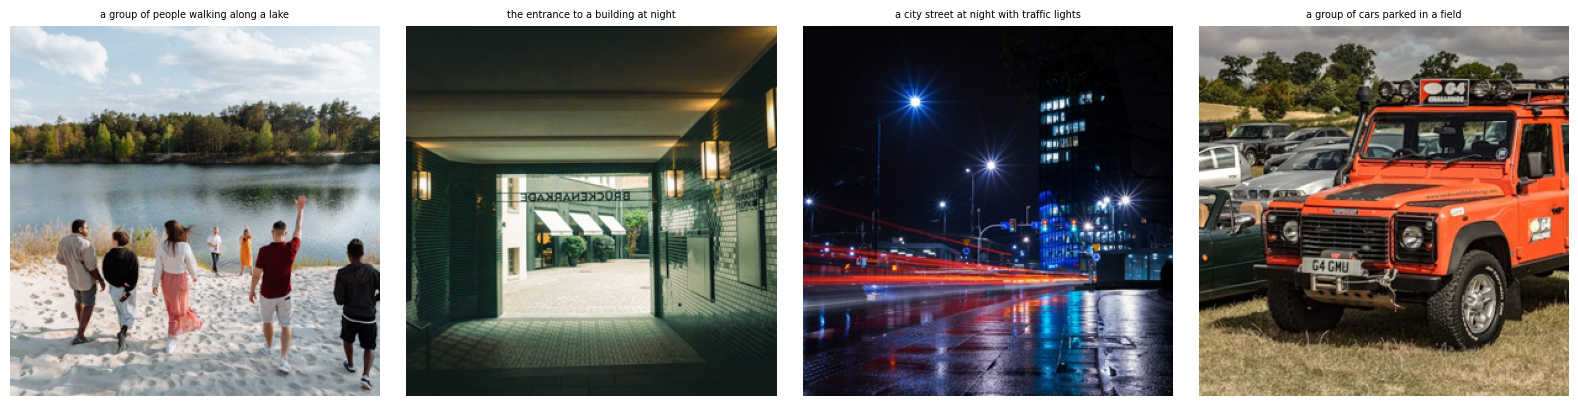

In [23]:
test_samples = random.sample(metadata, 4)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, ax in enumerate(axes.flat):
    item = test_samples[idx]
    path = os.path.join(IMAGE_DIR, item["filename"])

    if os.path.exists(path):
        img = Image.open(path).convert("RGB")
        w, h = img.size
        side = min(w, h)
        left = (w - side) // 2
        top = (h - side) // 2
        img = img.crop((left, top, left + side, top + side))
        img = img.resize((300, 300))
        ax.imshow(img)

    cap = get_caption(path)
    ax.set_title(f"{cap}", fontsize=7, wrap=True)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Ran it on all images
Took about 2 hours on my RTX 3050.

In [ ]:
results = []
total = len(metadata)
start = time.time()

print(f"Generating captions for {total} images...")

for i, item in enumerate(metadata):
    path = os.path.join(IMAGE_DIR, item["filename"])

    if not os.path.exists(path):
        continue

    cap = get_caption(path)
    cap_detail = get_detailed_caption(path)

    results.append({
        "image_id": item["image_id"],
        "filename": item["filename"],
        "category": item.get("category", "unknown"),
        "caption": cap,
        "caption_detailed": cap_detail
    })

    if (i + 1) % 500 == 0:
        elapsed = time.time() - start
        speed = (i + 1) / elapsed
        remaining = (total - i - 1) / speed / 60
        print(f"  {i+1}/{total} done | {speed:.1f} img/s | ~{remaining:.0f} min left")
        torch.cuda.empty_cache()

elapsed = time.time() - start
print(f"\nDone. {len(results)} images captioned in {elapsed/60:.1f} minutes")

### Saved everything

In [ ]:
with open("dataset_with_captions.json", "w") as f:
    json.dump(results, f, indent=2)

with open("dataset_with_captions.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["image_id", "filename", "category", "caption", "caption_detailed"])
    writer.writeheader()
    writer.writerows(results)

print("Saved: dataset_with_captions.json")
print("Saved: dataset_with_captions.csv")

## Step 5: Looking at the results

Checking what the dataset looks like and if the captions are any good.

In [18]:
with open("dataset_with_captions.json", "r") as f:
    results = json.load(f)

print(f"Total captioned images: {len(results)}")
print(f"\nImages per category:")

cat_counts = {}
for r in results:
    cat = r["category"]
    cat_counts[cat] = cat_counts.get(cat, 0) + 1

for cat, count in sorted(cat_counts.items(), key=lambda x: -x[1]):
    print(f"  {cat}: {count}")

Total captioned images: 10617

Images per category:
  street_scene: 1629
  crowd: 1623
  office_building: 1317
  people_walking: 1201
  vehicles: 1157
  indoor_spaces: 1086
  entrance_security: 1083
  parking_lot: 1044
  night_surveillance: 477


### Checking how many unique captions we got 

In [20]:
all_captions = [r["caption"] for r in results if r["caption"]]
unique_captions = set(all_captions)

print(f"Total captions: {len(all_captions)}")
print(f"Unique captions: {len(unique_captions)}")
print(f"Uniqueness ratio: {len(unique_captions)/len(all_captions)*100:.1f}%")

Total captions: 10617
Unique captions: 5690
Uniqueness ratio: 53.6%


### Most common words in the captions

In [ ]:
from collections import Counter

all_words = []
for r in results:
    if r["caption"]:
        all_words.extend(r["caption"].lower().split())

stop_words = {"a", "an", "the", "of", "in", "on", "is", "with", "and", "to", "at", "by", "for"}
filtered = [w for w in all_words if w not in stop_words]

common = Counter(filtered).most_common(20)

words, counts = zip(*common)
plt.figure(figsize=(12, 4))
plt.bar(words, counts, edgecolor="black", alpha=0.7)
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.title("Most Common Words in Captions")
plt.tight_layout()
plt.show()

### Random samples with both captions

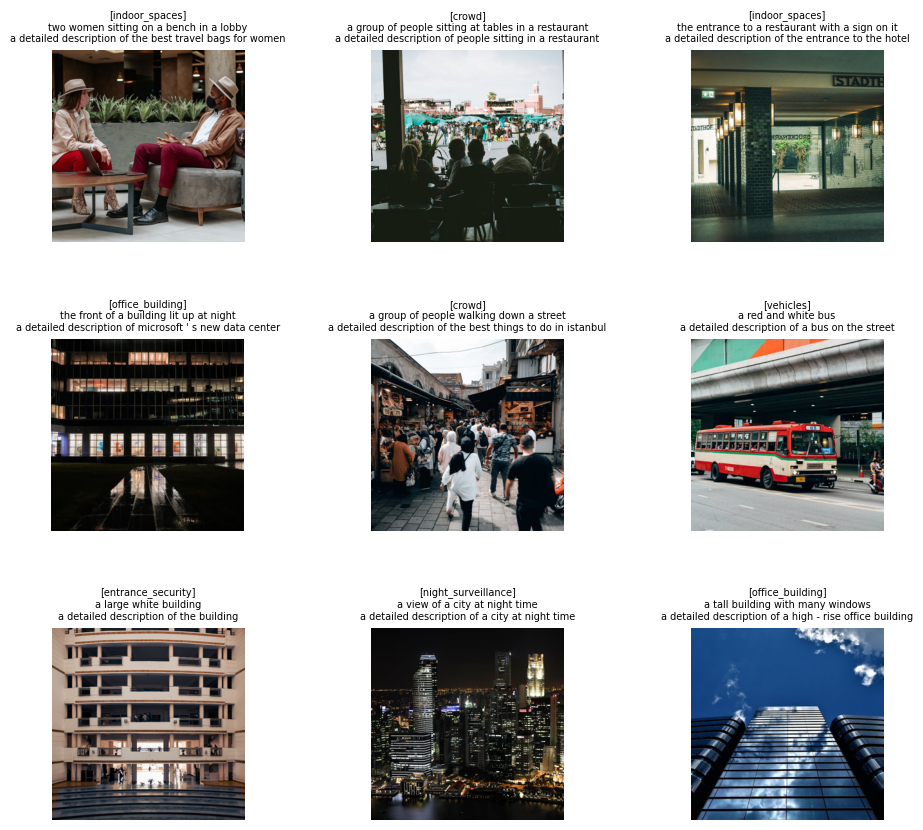

In [24]:
samples = random.sample(results, 9)
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for idx, ax in enumerate(axes.flat):
    item = samples[idx]
    path = os.path.join(IMAGE_DIR, item["filename"])

    if os.path.exists(path):
        img = Image.open(path).convert("RGB")
        w, h = img.size
        side = min(w, h)
        left = (w - side) // 2
        top = (h - side) // 2
        img = img.crop((left, top, left + side, top + side))
        img = img.resize((300, 300))
        ax.imshow(img)

    caption = item["caption"] if item["caption"] else "no caption"
    detailed = item["caption_detailed"] if item["caption_detailed"] else ""
    category = item.get("category", "unknown")

    ax.set_title(f"[{category}]\n{caption}\n{detailed}", fontsize=7)
    ax.axis("off")

plt.subplots_adjust(hspace=0.5, wspace=0.1)
plt.show()

## Done

- Scraped 10,617 images from Pexels across 12 surveillance-relevant categories
- Generated 2 captions per image using BLIP - basic and detailed
- Total: 10,617 images with 21,234 captions
- Saved as JSON and CSV

Picked these categories because they match what Eagle Eye's cameras actually deal with - people, vehicles, buildings, entrances, night scenes, crowds. The whole pipeline can scale to more images just by adding more search queries.